# 1 month salt budget test for panant-01 control, shelf only

This is from the experiment at /home/157/akm157/mom6/panant-01-zstar-ACCESSyr2/.     
Trying to see whether salinity change on shelf is primarily from advection vs surface fluxes.

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
lat_slice = slice(-79,-59)

# Importing data
paths_1 = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-01-zstar-ACCESSyr2-test-pan01_test_01-f7e0ea96/output000/*.ocean_month.nc'))
paths_2 = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-01-zstar-ACCESSyr2-test-pan01_test_01-f7e0ea96/output000/*.ocean_month_z.nc'))

In [3]:
# Time variant variables
def preprocess_1(ds):
    ds = ds[['wfo','lrunoff']].sel(yh=lat_slice)
    return ds

def preprocess_2(ds):
    ds = ds[['so','S_advection_xy','Sh_tendency_vert_remap','osalttend','osaltpmdiff','osaltdiff','boundary_forcing_salt_tendency']].sel(yh=lat_slice)
    return ds

pan = xr.open_mfdataset(paths_1, preprocess = preprocess_1, chunks = 'auto')
pan_z = xr.open_mfdataset(paths_2, preprocess = preprocess_2, chunks = 'auto')

In [4]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [5]:
depth = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_static.nc')['deptho']
land_mask = (0 * depth).fillna(1)
land = xr.where(np.isnan(depth.rename('land_1')), 1, np.nan)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom6_01')

In [6]:
lhs_salt = {
    'salt_tendency': pan_z.osalttend
}

rhs_salt = {
    # Advection
    'advection_xy': pan_z.S_advection_xy,
    'advection_vert': pan_z.Sh_tendency_vert_remap,

    # Diffusion / mixing
    'vertical_diffusion': pan_z.osaltdiff,
    'neutral_diffusion': pan_z.osaltpmdiff,

    # Surface & boundary forcing
    'surface_forcing': pan_z.boundary_forcing_salt_tendency,
}

Cell below is a work in progress:

At the moment taking `time`=0 to just look at first month - but I'm unsure this is still giving me the right evolution over time that I am looking for.

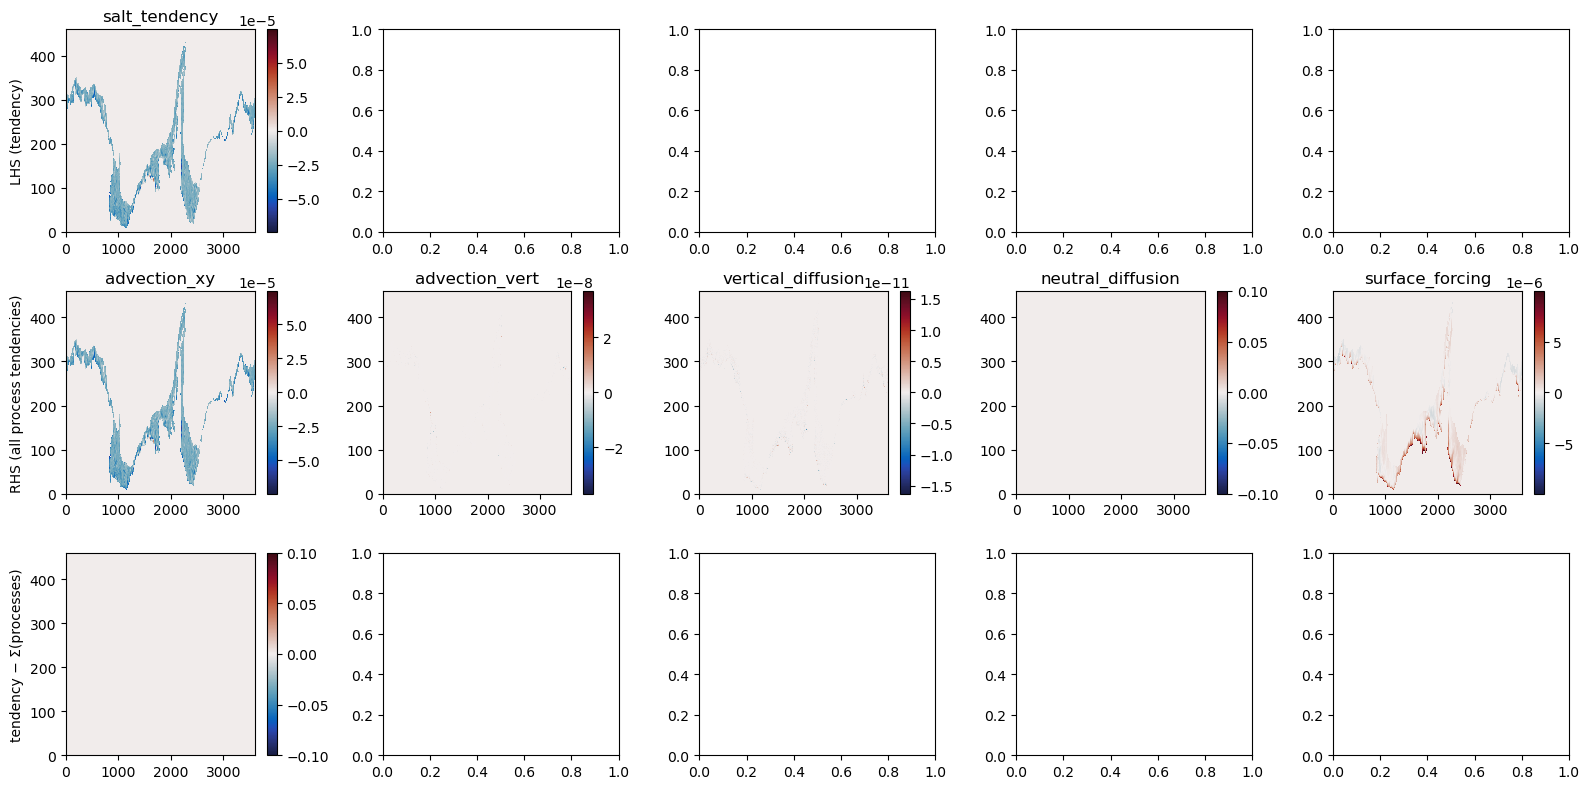

In [7]:
zdim = 'z_l'  # MOM6 vertical grid dimension

fig, ax = plt.subplots(
    figsize=(16, 8),
    nrows=3,
    ncols=max(len(lhs_salt), len(rhs_salt))
)
ax = ax.reshape(3, -1)  # flatten for consistent indexing

# -----------------------
# LHS terms
# -----------------------
for i, (name, da) in enumerate(lhs_salt.items()):

    da_masked = da.where(shelf_mask == 1)

    da2d = da_masked.sum(zdim).squeeze()

    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)

    da2d = da2d.compute()

    vmax = np.nanmax(np.abs(da2d))

    im = ax[0, i].pcolormesh(
        da2d, cmap=cm.cm.balance,
        vmax=vmax, vmin=-vmax
    )

    plt.colorbar(im, ax=ax[0, i])
    ax[0, i].set_title(name)

# -----------------------
# RHS terms
# -----------------------
for i, (name, da) in enumerate(rhs_salt.items()):

    da_masked = da.where(shelf_mask == 1)

    da2d = da_masked.sum(zdim).squeeze()

    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)

    da2d = da2d.compute()

    vmax = np.nanmax(np.abs(da2d))

    im = ax[1, i].pcolormesh(
        da2d, cmap=cm.cm.balance,
        vmax=vmax, vmin=-vmax
    )

    plt.colorbar(im, ax=ax[1, i])
    ax[1, i].set_title(name)

# -----------------------
# Closure residual
# -----------------------
lhs_total = pan_z.osalttend.where(shelf_mask == 1)

rhs_total = (
    pan_z.S_advection_xy
    + pan_z.Sh_tendency_vert_remap
    + pan_z.boundary_forcing_salt_tendency
    + pan_z.osaltdiff
    + pan_z.osaltpmdiff
).where(shelf_mask == 1)

residual = (lhs_total - rhs_total).sum(zdim).squeeze()

if 'time' in residual.dims:
    residual = residual.isel(time=0)

residual = residual.compute()

vmax = np.abs(residual).max()

im = ax[2, 0].pcolormesh(
    residual, cmap=cm.cm.balance,
    vmin=-vmax, vmax=vmax
)

plt.colorbar(im, ax=ax[2, 0])

# -----------------------
# Row labels
# -----------------------
ax[0, 0].set_ylabel('LHS (tendency)')
ax[1, 0].set_ylabel('RHS (all process tendencies)')
ax[2, 0].set_ylabel('tendency − Σ(processes)')

plt.tight_layout()


#### Checking if we have closure:   
We are told that for the budget to be considered “closed” the difference between the LHS and RHS should be approximately 12 orders of magnitude smaller than the contributing terms.   
We also want to check whether there is off-shelf advection.  

In [8]:
# Note residual = (lhs_total - rhs_total).sum(zdim).squeeze()
residual

<xarray.DataArray (yh: 460, xh: 3600)> Size: 7MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)
Coordinates:
  * yh       (yh) float64 4kB -79.0 -78.95 -78.91 ... -59.14 -59.08 -59.03
  * xh       (xh) float64 29kB -279.9 -279.8 -279.7 -279.6 ... 79.75 79.85 79.95
    time     object 8B 1991-01-16 12:00:00

In [9]:
residual.max().compute()

<xarray.DataArray ()> Size: 8B
array(0.)
Coordinates:
    time     object 8B 1991-01-16 12:00:00

In [10]:
residual.min().compute()

<xarray.DataArray ()> Size: 8B
array(0.)
Coordinates:
    time     object 8B 1991-01-16 12:00:00

So budget is closed. Can we approximate to **tendency = advection + surface forcing**? Check relative magnitude of LHS terms. 

In [11]:
# testing individual diagnostics
tendency = pan_z.osalttend
adv_horizontal = pan_z.S_advection_xy
adv_vertical = pan_z.Sh_tendency_vert_remap
surface_forcing = pan_z.boundary_forcing_salt_tendency
diff_1 = pan_z.osaltdiff
diff_2 = pan_z.osaltpmdiff

In [12]:
tendency_plot = tendency.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
adv_hor_plot = adv_horizontal.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
adv_vert_plot = adv_vertical.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
surface_plot = surface_forcing.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
diff_1_plot = diff_1.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
diff_2_plot = diff_2.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()

In [13]:
tendency_plot = tendency_plot.compute()
adv_hor_plot = adv_hor_plot.compute()
adv_vert_plot = adv_vert_plot.compute()

In [14]:
surface_plot = surface_plot.compute()
diff_1_plot = diff_1_plot.compute()
diff_2_plot = diff_2_plot.compute()

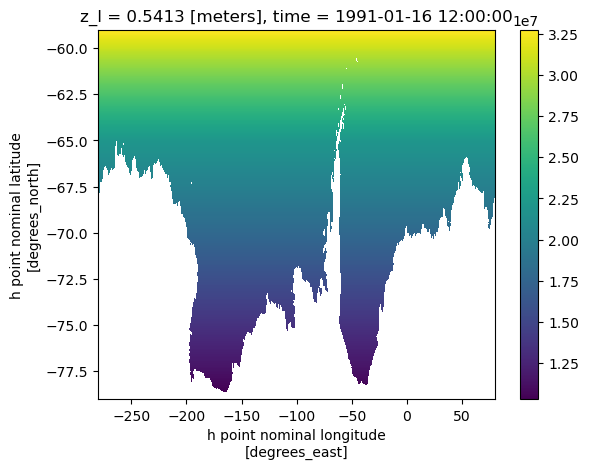

In [15]:
# Doing spatial average
area = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_static.nc')['areacello']
var = pan_z.so.isel(time=0,z_l=0)
area_corr = area*(var*0 +1)
area_corr.plot()

In [16]:
tendency_ave = (area_corr * tendency_plot).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
adv_hor_ave = (area_corr * adv_hor_plot).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
adv_vert_ave = (area_corr * adv_vert_plot).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
surface_ave = (area_corr * surface_plot).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
diff_1_ave = (area_corr * diff_1_plot).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
diff_2_ave = (area_corr * diff_2_plot).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])

In [17]:
tendency_ave = tendency_ave.load()
adv_hor_ave = adv_hor_ave.load()
tendency_ave = tendency_ave.load()
tendency_ave = tendency_ave.load()
tendency_ave = tendency_ave.load()
tendency_ave = tendency_ave.load()

**On average, how much salt per square metre is being added/removed from the shelf (full-depth integrated), due to...**

In [18]:
print("tendency =", tendency_ave.values, "\nhorizontal advection =", adv_hor_ave.values, "\nvertical advection =", adv_vert_ave.values, "\nsurface forcing =", 
      surface_ave.values, "\ndiffusion 1 =", diff_1_ave.values, "\ndiffusion 2 =", diff_2_ave.values)

tendency = -2.3906707e-05 
horizontal advection = -2.4410076e-05 
vertical advection = -4.799896e-13 
surface forcing = 5.0337326e-07 
diffusion 1 = -1.0502631e-16 
diffusion 2 = 0.0


So yes, tendency, horizontal advection, and surface forcing are the dominant terms.  
We also see that the tendency is dominated by horizontal advection, far more than surface forcing.  
**BUT** this is just the control experiment. We need to look at the anomaly (pert - control) to see what's actually happening.

In [19]:
# Checking closure again
print("LHS =", tendency_ave.values, "\nRHS =", (adv_hor_ave + adv_vert_ave + surface_ave + diff_1_ave + diff_2_ave).values)

LHS = -2.3906707e-05 
RHS = -2.3906703e-05


Pretty close!

In [21]:
# Meltwater values
tendency_ave_M = -6.817934e-07 
adv_hor_ave_M = -6.716956e-07 
adv_vert_ave_M = -3.4678998e-13 
surface_ave_M = -1.0096756e-08 
diff_1_ave_M = 8.8361905e-16 
diff_2_ave_M = 0.0

# renaming control values
tendency_ave_C = tendency_ave.values
adv_hor_ave_C = adv_hor_ave.values
adv_vert_ave_C = adv_vert_ave.values
surface_ave_C = surface_ave.values
diff_1_ave_C = diff_1_ave.values
diff_2_ave_C = diff_2_ave.values

In [22]:
tendency_ave_anom = tendency_ave_M - tendency_ave_C
adv_hor_ave_anom = adv_hor_ave_M - adv_hor_ave_C
adv_vert_ave_anom = adv_vert_ave_M - adv_vert_ave_C
surface_ave_anom = surface_ave_M - surface_ave_C
diff_1_ave_anom = diff_1_ave_M - diff_1_ave_C
diff_2_ave_anom = diff_2_ave_M - diff_2_ave_C

In [43]:
# Term labels
terms = [
    "Tendency",
    "Adv Hor",
    "Adv Vert",
    "Surface forcing",
    "Diff 1",
    "Diff 2"
]

# Anomaly values
anoms = [
    tendency_ave_anom,
    adv_hor_ave_anom,
    adv_vert_ave_anom,
    surface_ave_anom,
    diff_1_ave_anom,
    diff_2_ave_anom
]

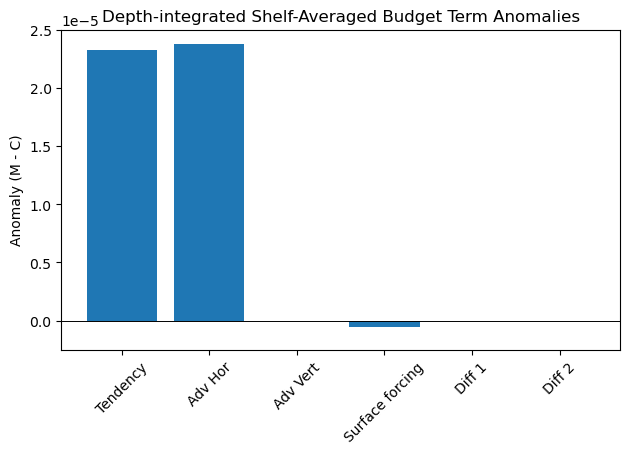

In [44]:
# Create figure
plt.figure()
plt.bar(terms, anoms)

plt.ylabel("Anomaly (M - C)")
plt.ylim(-0.25e-5,2.5e-5)
plt.axhline(0, color='black', linewidth=0.7)
plt.title("Depth-integrated Shelf-Averaged Budget Term Anomalies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation:
- Tendency indicates meltwater experiment freshens less on the shelf compared to control (when depth-integrated)??? 
   - This does not look correct!
- Freshening due to surface forcing when we add meltwater. 

In [45]:
# M values
M_vals = [
    tendency_ave_M,
    adv_hor_ave_M,
    adv_vert_ave_M,
    surface_ave_M,
    diff_1_ave_M,
    diff_2_ave_M
]

# C values
C_vals = [
    tendency_ave_C,
    adv_hor_ave_C,
    adv_vert_ave_C,
    surface_ave_C,
    diff_1_ave_C,
    diff_2_ave_C
]

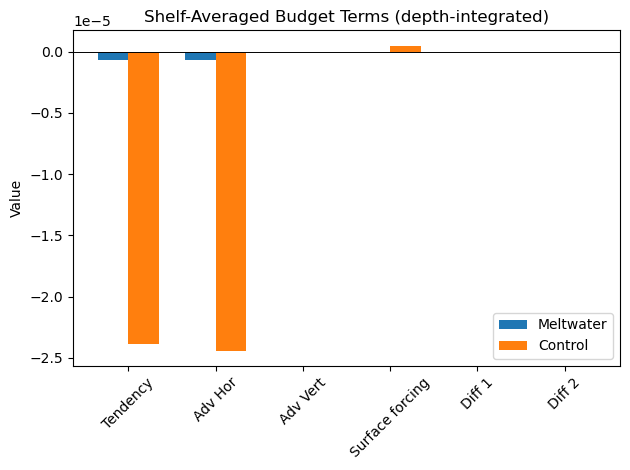

In [46]:
x = np.arange(len(terms))
width = 0.35

plt.figure()
plt.bar(x - width/2, M_vals, width, label="Meltwater")
plt.bar(x + width/2, C_vals, width, label="Control")

plt.xticks(x, terms, rotation=45)
plt.axhline(0, color='black', linewidth=0.7)
plt.ylabel("Value")
plt.title("Shelf-Averaged Budget Terms (depth-integrated)")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation:
- both experiments freshen on the shelf and export salt off the shelf, but the control experiment does this way more. 

### Surface and bottom salinity for reference

In [48]:
import pandas as pd

In [49]:
data_1a_time = xr.open_dataarray('/g/data/g40/kc5856/access_panan_ssp126_SWMT/botsalt_anom_pan01.nc', chunks = 'auto')
data_1b_time = xr.open_dataarray('/g/data/g40/kc5856/access_panan_ssp126_SWMT/topsalt_anom_pan01.nc', chunks = 'auto')

In [50]:
data_1a_time_new = data_1a_time.to_series()
data_1b_time_new = data_1b_time.to_series()

data_1a_time_new = data_1a_time_new['2001-01-01':'2010-10-16']
data_1b_time_new = data_1b_time_new['2001-01-01':'2010-10-16']

data_1a_time_new.index = range(1, len(data_1a_time_new)+1)
data_1b_time_new.index = range(1, len(data_1b_time_new)+1)

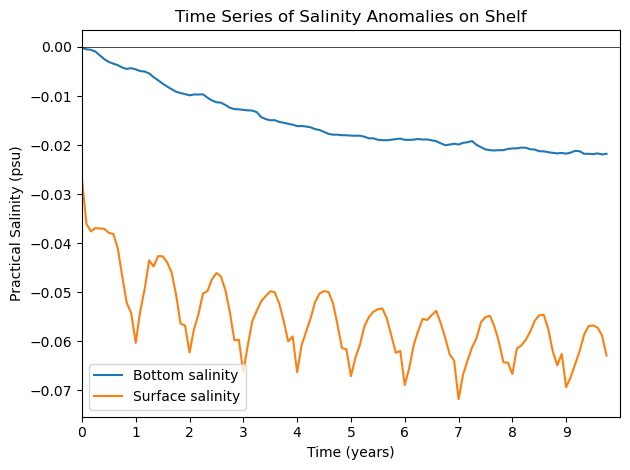

In [57]:
fig, ax = plt.subplots()

data_1a_time_new.plot(ax=ax, label="Bottom salinity")
data_1b_time_new.plot(ax=ax, label="Surface salinity")

ax.set_xticks(range(1, 121, 12))
ax.set_xticklabels([str(j) for j in range(0, 10)])

ax.axhline(0, color="black", linewidth=0.5)

ax.set_xlabel("Time (years)")
ax.set_xlim(1, 121)
# ax.set_ylim(-1.30, -0.70)

ax.set_ylabel("Practical Salinity (psu)")
ax.legend(loc="lower left")
ax.set_title("Time Series of Salinity Anomalies on Shelf")

plt.tight_layout()
plt.show()

### Thoughts
The salt flux anomalies feel a bit counter intuitive. BUT...
- this is just a salt budget, does not include freshwater budget.
- Control may have lose more salt than meltwater when it comes to the salt fluxes, but meltwater still be overall fresher due to a great freshwater flux (expected due to runoff term). 